# 📉 Customer Churn Prediction & Deployment Pipeline

**Goal:** predict which telecom customers are about to leave, so the business can act *before* they do.

| | |
|---|---|
| **Dataset** | IBM Telco Customer Churn (7,043 customers, 21 columns) |
| **Models** | Logistic Regression · Random Forest · XGBoost · Keras Neural Network |
| **Tuning** | `RandomizedSearchCV` / `GridSearchCV`, 5-fold cross-validation |
| **Final model** | Tuned Logistic Regression with a decision threshold of **0.30** |
| **Deployment** | FastAPI REST endpoint (`main.py`) |

### Notebook map
1. Data loading & inspection
2. Exploratory data analysis (EDA)
3. Cleaning, split & preprocessing pipeline
4. Baseline models (LogReg, Random Forest, XGBoost)
5. Neural network (Keras)
6. Hyperparameter tuning
7. Threshold tuning for recall
8. Final evaluation, model selection & export

> **Run order matters.** Cells depend on variables from earlier cells. If something breaks, restart the kernel and use **Run All**.

## 📏 Metrics cheat-sheet

Only ~27% of customers churn, so the data is **imbalanced**. Accuracy alone is misleading here: a model that always says "no churn" scores ~73% while catching zero churners.

| Metric | Question it answers | Formula |
|---|---|---|
| **Accuracy** | How many predictions were correct overall? | (TP + TN) / total |
| **Precision** | When the model raises a churn alert, how often is it right? | TP / (TP + FP) |
| **Recall** | Of all real churners, how many did we catch? | TP / (TP + FN) |
| **F1** | Balance between precision and recall | 2·P·R / (P + R) |
| **ROC-AUC** | Chance that a random churner is ranked above a random non-churner (threshold-independent) | area under ROC curve |

**Confusion matrix:** TP = churner caught · FP = false alarm · FN = churner missed · TN = loyal customer correctly left alone.

For churn, **a missed churner (FN) usually costs more than a false alarm (FP)**, which is why recall matters most.

## 1️⃣ Data loading

Load the raw Telco churn CSV and check its shape. We expect **7,043 rows × 21 columns**.

In [2]:
import pandas as pd

df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)   # (7043, 21)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2️⃣ Data inspection

`df.info()` shows column names, dtypes and non-null counts.

What to look for:
- Most columns are `object` (text / categorical).
- `TotalCharges` should be numeric but is stored as text, because a few rows contain a blank string. We fix this in the cleaning step.

In [ ]:
df.info()

## 3️⃣ Target distribution (class imbalance)

How many customers churned vs. stayed? This decides which metrics we can trust.

Roughly **73.5% stayed / 26.5% churned**, so the data is imbalanced. This is why we track Precision, Recall, F1 and ROC-AUC instead of relying on accuracy.

In [4]:
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


## 4️⃣ Exploratory visuals

Three quick plots to see what separates churners from loyal customers:
1. **Contract type** vs. churn
2. **Tenure** (months with the company) vs. churn
3. **Monthly charges** vs. churn

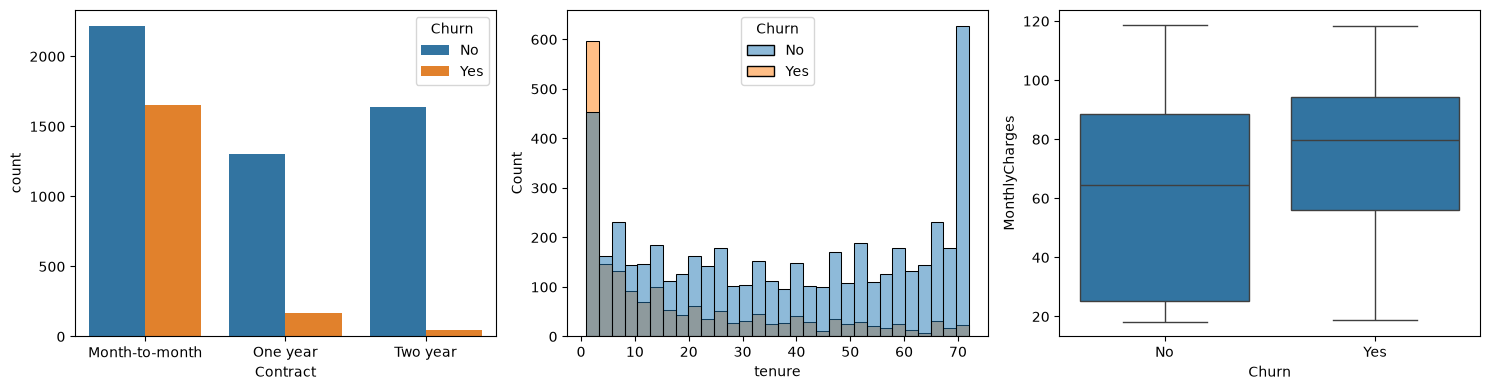

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(x="Contract", hue="Churn", data=df, ax=ax[0])
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, ax=ax[1])
sns.boxplot(x="Churn", y="MonthlyCharges", data=df, ax=ax[2])
plt.tight_layout()
plt.show()

### 🔎 What the plots tell us

- **Contract:** month-to-month customers churn far more than one- or two-year customers.
- **Tenure:** churn is concentrated among new customers; long-tenured customers rarely leave.
- **Monthly charges:** churners tend to pay higher monthly bills.

These patterns are exactly what the models should pick up, and they also explain why a simple linear model performs so well on this dataset.

## 5️⃣ Cleaning, train/test split & preprocessing pipeline

This single cell makes everything reproducible, in the correct order:

| Step | Why |
|---|---|
| `TotalCharges` → numeric (`errors="coerce"`) | The column is text because 11 rows hold a blank string |
| Drop those 11 rows | They are brand-new customers (`tenure = 0`) with no total charge yet; 0.16% of the data |
| Drop `customerID` | A unique ID carries no signal and lets models memorise rows |
| `Churn` → 1 / 0 | Metrics like precision/recall need a numeric target |
| **Stratified 80/20 split**, `random_state=42` | Keeps the ~26.5% churn rate in both sets; fixed seed makes results reproducible |
| `ColumnTransformer` | `StandardScaler` for numeric columns, `OneHotEncoder` for categorical columns |

**Why one-hot encoding?** Label encoding would invent a fake order (DSL < Fiber < None). One-hot gives each category its own 0/1 column. `handle_unknown="ignore"` stops the API from crashing on a category it never saw.

**Leakage guard:** the preprocessor is only *defined* here. It is fitted inside a `Pipeline`, so scaling/encoding statistics are learned from training data only (and from each training fold during cross-validation).

✅ Sanity check: expect `False`, `4 15`, and `(7032, 19) (7032, 20)`.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna(subset=["TotalCharges"]).reset_index(drop=True)
df = df.drop(columns=["customerID"])
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

print("customerID" in X.columns)     # False
print(len(num_cols), len(cat_cols))  # 4 15
print(X.shape, df.shape)             # (7032, 19) (7032, 20)

False
4 15
(7032, 19) (7032, 20)


C:\Users\aquar\AppData\Local\Temp\ipykernel_5888\1315490869.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object"]).columns.tolist()


## 6️⃣ Baseline models

Three models, each wrapped in the same `Pipeline(preprocessor → model)`, evaluated with one shared `evaluate()` helper so the comparison is fair.

| Model | Role |
|---|---|
| **Logistic Regression** | Simple, fast, interpretable baseline |
| **Random Forest** | Bagging: many trees voting in parallel |
| **XGBoost** | Boosting: trees built sequentially, each fixing the previous one's errors |

`evaluate()` stores Accuracy, Precision, Recall, F1 and ROC-AUC in the `results` dict and prints the confusion matrix.

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

results = {}

def evaluate(name, model):
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    results[name] = {
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba),
    }
    print(name)
    print(confusion_matrix(y_test, pred))

baseline = Pipeline([("prep", preprocessor),
                     ("model", LogisticRegression(max_iter=1000))])
baseline.fit(X_train, y_train)
evaluate("Logistic Regression", baseline)

rf = Pipeline([("prep", preprocessor),
               ("model", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))])
rf.fit(X_train, y_train)
evaluate("Random Forest", rf)

xgb = Pipeline([("prep", preprocessor),
                ("model", XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                                        eval_metric="logloss", random_state=42))])
xgb.fit(X_train, y_train)
evaluate("XGBoost", xgb)

pd.DataFrame(results).T.round(3)

Logistic Regression
[[917 116]
 [160 214]]
Random Forest
[[927 106]
 [189 185]]
XGBoost
[[913 120]
 [173 201]]


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.804,0.648,0.572,0.608,0.836
Random Forest,0.790,0.636,0.495,0.556,0.813
XGBoost,0.792,0.626,0.537,0.578,0.835


### 📊 Reading the baseline results

- **Logistic Regression is already the strongest** (ROC-AUC 0.836). The data is small and mostly linear, so complex models have little extra to learn.
- **Random Forest is weakest**, with recall of only 0.495: with default settings it leans towards the majority class ("no churn").
- **Every model has low recall (~0.50 to 0.57).** The default 0.5 threshold is too conservative for imbalanced data. We address this in the threshold-tuning step.

## 7️⃣ Neural network: data preparation

Keras needs a dense NumPy array, not a scikit-learn pipeline, so we preprocess separately.

- `clone(preprocessor)` makes a fresh, unfitted copy so the baseline pipelines stay untouched.
- `fit_transform` on **train only**, `transform` on test (no leakage).
- `.toarray()` converts the sparse one-hot matrix to dense.
- `set_random_seed(42)` fixes weight initialisation, dropout and shuffling for reproducibility.

✅ Expect `(5625, 45) (1407, 45)`: 4 numeric + 41 one-hot columns.

In [3]:
import numpy as np
import tensorflow as tf
from sklearn.base import clone
from scipy import sparse

tf.keras.utils.set_random_seed(42)

prep_nn = clone(preprocessor)
X_train_nn = prep_nn.fit_transform(X_train)
X_test_nn = prep_nn.transform(X_test)

if sparse.issparse(X_train_nn):
    X_train_nn = X_train_nn.toarray()
    X_test_nn = X_test_nn.toarray()

print(X_train_nn.shape, X_test_nn.shape)

(5625, 45) (1407, 45)


## 8️⃣ Neural network: architecture & training

```
Input (45) → Dense 64 (ReLU) → Dropout 0.3 → Dense 32 (ReLU) → Dropout 0.3 → Dense 1 (sigmoid)
```

| Component | Purpose |
|---|---|
| **ReLU** | Lets the network learn non-linear patterns |
| **Dropout 0.3** | Randomly switches off 30% of neurons per step to reduce overfitting |
| **Sigmoid output** | Squeezes output into a 0–1 churn probability |
| **Binary cross-entropy** | Loss that measures how far the probability is from the true label |
| **Adam (lr = 0.001)** | Optimiser that updates the weights |
| **Early stopping** | Stops when validation AUC fails to improve for 10 epochs and restores the best weights |
| **`validation_split=0.2`** | Holds out part of the training data for monitoring; the test set is never touched |

In [4]:
from tensorflow import keras
from tensorflow.keras import layers

nn = keras.Sequential([
    layers.Input(shape=(X_train_nn.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),
])

nn.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
           loss="binary_crossentropy",
           metrics=[keras.metrics.AUC(name="auc")])

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_auc", mode="max", patience=10, restore_best_weights=True)

history = nn.fit(X_train_nn, y_train, validation_split=0.2,
                 epochs=100, batch_size=32, callbacks=[early_stop], verbose=1)

proba_nn = nn.predict(X_test_nn).ravel()
pred_nn = (proba_nn >= 0.5).astype(int)

results["Neural Network"] = {
    "Accuracy": accuracy_score(y_test, pred_nn),
    "Precision": precision_score(y_test, pred_nn),
    "Recall": recall_score(y_test, pred_nn),
    "F1": f1_score(y_test, pred_nn),
    "ROC-AUC": roc_auc_score(y_test, proba_nn),
}
print(confusion_matrix(y_test, pred_nn))
pd.DataFrame(results).T.round(3)

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - auc: 0.7493 - loss: 0.5043 - val_auc: 0.8420 - val_loss: 0.4200
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.8167 - loss: 0.4489 - val_auc: 0.8519 - val_loss: 0.4099
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.8258 - loss: 0.4412 - val_auc: 0.8552 - val_loss: 0.4051
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.8385 - loss: 0.4264 - val_auc: 0.8569 - val_loss: 0.4022
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.8359 - loss: 0.4297 - val_auc: 0.8566 - val_loss: 0.4027
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.8413 - loss: 0.4228 - val_auc: 0.8573 - val_loss: 0.4019
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.8412 - loss: 0.4252 - val_auc: 0.8579 - val_loss: 0.4007
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.8473 - loss: 0.4181 - val_auc: 0.8568 - val_loss: 0.4020
Epoch 9/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.804,0.648,0.572,0.608,0.836
Random Forest,0.790,0.636,0.495,0.556,0.813
XGBoost,0.792,0.626,0.537,0.578,0.835
Neural Network,0.800,0.641,0.559,0.597,0.834


### 🧠 Result

The neural network reaches ROC-AUC **0.834**, essentially identical to Logistic Regression. On a small tabular dataset like this, deep learning offers **no measurable benefit** over a simple model, and that is a legitimate finding worth reporting.

## 9️⃣ Hyperparameter tuning: XGBoost

`RandomizedSearchCV` samples **30 random combinations** of XGBoost settings and scores each with **5-fold cross-validation** (150 fits in total) on the **training set only**. The test set stays untouched.

Parameters searched: number of trees, tree depth, learning rate, row/column subsampling and minimum child weight.

The `model__` prefix routes each parameter to the `model` step of the pipeline. Because the preprocessor lives inside the pipeline, it is re-fitted on each fold's training part, so there is no leakage.

`Best CV ROC-AUC` is the average validation score of the winning setting.

In [5]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [2, 3, 4, 5, 6],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__min_child_weight": [1, 3, 5],
}

xgb_base = Pipeline([("prep", preprocessor),
                     ("model", XGBClassifier(eval_metric="logloss", random_state=42))])

search = RandomizedSearchCV(xgb_base, param_dist, n_iter=30, scoring="roc_auc",
                            cv=5, random_state=42, n_jobs=-1, verbose=1)
search.fit(X_train, y_train)

print("Best CV ROC-AUC:", round(search.best_score_, 4))
print(search.best_params_)

xgb_tuned = search.best_estimator_
evaluate("XGBoost (tuned)", xgb_tuned)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV ROC-AUC: 0.8497
{'model__subsample': 0.7, 'model__n_estimators': 500, 'model__min_child_weight': 3, 'model__max_depth': 2, 'model__learning_rate': 0.03, 'model__colsample_bytree': 1.0}
XGBoost (tuned)
[[920 113]
 [177 197]]


## 🔟 Hyperparameter tuning: Logistic Regression

`GridSearchCV` exhaustively tries every combination of:
- **`C`**: inverse regularisation strength (smaller = stronger regularisation)
- **`class_weight`**: `None` vs. `"balanced"` (gives churners more weight during training)

Scored with 5-fold CV on ROC-AUC. The table printed at the end now holds all six models for comparison.

In [6]:
from sklearn.model_selection import GridSearchCV

lr_base = Pipeline([("prep", preprocessor),
                    ("model", LogisticRegression(max_iter=2000))])

lr_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__class_weight": [None, "balanced"],
}

lr_search = GridSearchCV(lr_base, lr_grid, scoring="roc_auc", cv=5, n_jobs=-1)
lr_search.fit(X_train, y_train)

print("Best CV ROC-AUC:", round(lr_search.best_score_, 4))
print(lr_search.best_params_)

lr_tuned = lr_search.best_estimator_
evaluate("Logistic Regression (tuned)", lr_tuned)
pd.DataFrame(results).T.round(3)

Best CV ROC-AUC: 0.8462
{'model__C': 10, 'model__class_weight': None}
Logistic Regression (tuned)
[[913 120]
 [161 213]]


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.804,0.648,0.572,0.608,0.836
Random Forest,0.790,0.636,0.495,0.556,0.813
XGBoost,0.792,0.626,0.537,0.578,0.835
Neural Network,0.800,0.641,0.559,0.597,0.834
XGBoost (tuned),0.794,0.635,0.527,0.576,0.840
Logistic Regression (tuned),0.800,0.640,0.570,0.603,0.835


### ⚖️ Model selection

| Model | CV ROC-AUC (train) | Test ROC-AUC |
|---|---|---|
| XGBoost (tuned) | 0.8497 | 0.840 |
| Logistic Regression (tuned) | 0.8462 | 0.835 |

The gap is **0.0035**, well within normal cross-validation noise. When two models perform equally, we pick the **simpler, faster and more interpretable one**: Logistic Regression.

Tuning barely moved the needle. The bigger win comes next.

## 1️⃣1️⃣ Threshold tuning

A classifier outputs a **probability**; the **threshold** converts it into a yes/no decision. The default is 0.5, which is too cautious for an imbalanced problem.

**How we choose it without cheating:**
1. `cross_val_predict` produces an out-of-fold probability for every training row (each prediction comes from a model that never saw that row).
2. Sweep thresholds from 0.20 to 0.70 and compute Precision, Recall and F1.
3. Pick the threshold with the highest F1.

The threshold is picked on **training data only**. Looking at the test set to pick it would be leakage.

In [7]:
from sklearn.model_selection import cross_val_predict

best_model = lr_tuned   # ya xgb_tuned, jiska CV ROC-AUC behtar ho

cv_proba = cross_val_predict(best_model, X_train, y_train, cv=5,
                             method="predict_proba")[:, 1]

thresholds = np.arange(0.20, 0.71, 0.05)
rows = []
for t in thresholds:
    p = (cv_proba >= t).astype(int)
    rows.append((round(t, 2), precision_score(y_train, p),
                 recall_score(y_train, p), f1_score(y_train, p)))

th_df = pd.DataFrame(rows, columns=["Threshold", "Precision", "Recall", "F1"]).round(3)
print(th_df)

best_t = th_df.loc[th_df["F1"].idxmax(), "Threshold"]
print("Best threshold (F1):", best_t)

    Threshold  Precision  Recall     F1
0        0.20      0.476   0.872  0.615
1        0.25      0.513   0.819  0.631
2        0.30      0.541   0.767  0.634
3        0.35      0.566   0.719  0.633
4        0.40      0.583   0.656  0.617
5        0.45      0.616   0.602  0.609
6        0.50      0.651   0.550  0.596
7        0.55      0.685   0.491  0.572
8        0.60      0.714   0.400  0.513
9        0.65      0.751   0.306  0.435
10       0.70      0.793   0.211  0.333
Best threshold (F1): 0.3


### 📈 Reading the sweep

- Lower threshold → **recall rises, precision falls**. This is the classic trade-off.
- F1 peaks at **0.30** (F1 ≈ 0.634), so that becomes our operating point.
- At 0.30 the cross-validated recall is ~77% with ~54% precision.

## 1️⃣2️⃣ Final evaluation on the test set

The chosen threshold (0.30) is applied **once** to the untouched test set.

In [8]:
proba_test = best_model.predict_proba(X_test)[:, 1]
pred_t = (proba_test >= best_t).astype(int)

results["Final (tuned + threshold)"] = {
    "Accuracy": accuracy_score(y_test, pred_t),
    "Precision": precision_score(y_test, pred_t),
    "Recall": recall_score(y_test, pred_t),
    "F1": f1_score(y_test, pred_t),
    "ROC-AUC": roc_auc_score(y_test, proba_test),
}
print(confusion_matrix(y_test, pred_t))
pd.DataFrame(results).T.round(3)

[[759 274]
 [ 90 284]]


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.804,0.648,0.572,0.608,0.836
Random Forest,0.790,0.636,0.495,0.556,0.813
XGBoost,0.792,0.626,0.537,0.578,0.835
Neural Network,0.800,0.641,0.559,0.597,0.834
XGBoost (tuned),0.794,0.635,0.527,0.576,0.840
Logistic Regression (tuned),0.800,0.640,0.570,0.603,0.835
Final (tuned + threshold),0.741,0.509,0.759,0.609,0.835


### 🏁 Final outcome

| | Threshold 0.50 | **Threshold 0.30** |
|---|---|---|
| Churners caught (TP) | 213 | **284** |
| Churners missed (FN) | 161 | **90** |
| False alarms (FP) | 120 | 274 |
| Recall | 0.570 | **0.759** |
| Precision | 0.640 | 0.509 |
| Accuracy | 0.800 | 0.741 |
| ROC-AUC | 0.835 | 0.835 |

**71 additional churners are caught**, at the cost of 154 more false alarms. Accuracy drops, but for churn that is an acceptable trade: a retention offer sent to a loyal customer is cheap, while losing a customer is expensive.

ROC-AUC is unchanged because it is threshold-independent. We only moved the *operating point*; the model itself did not change.

## 1️⃣3️⃣ Confirm the selected model

A quick check of exactly what will be deployed: the model type, its hyperparameters and the chosen threshold.

In [10]:
print(type(best_model.named_steps["model"]).__name__)
print(best_model.named_steps["model"].get_params())
print("Threshold:", best_t)

LogisticRegression
{'C': 10, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 2000, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
Threshold: 0.3


## 1️⃣4️⃣ Export for deployment

Save the **entire pipeline** (preprocessor + model) with `joblib`, and the threshold as JSON.

Saving the whole pipeline means the API needs no separate preprocessing code, and training and serving always transform data identically (no *training-serving skew*).

Output files:
- `model/churn_pipeline.joblib`
- `model/threshold.json`

In [11]:
import joblib, json, os

os.makedirs("model", exist_ok=True)
joblib.dump(best_model, "model/churn_pipeline.joblib")
with open("model/threshold.json", "w") as f:
    json.dump({"threshold": float(best_t)}, f)

print("Saved")

Saved


## 🚀 Next steps

1. Serve the model with FastAPI: `uvicorn main:app --reload`, then open `http://127.0.0.1:8000/docs`.
2. Ideas to improve further: feature engineering (e.g. `TotalCharges / tenure`), `class_weight` or SMOTE inside CV, probability calibration, SHAP explanations, cost-based threshold selection.